## Introduction

In questo laboratorio viene affrontato un problema di sentiment analysis, con l'obiettivo di classificare recensioni testuali come positive o negative utilizzando un modello Transformer pre-addestrato.

Il laboratorio analizza diversi approcci per adattare DistilBERT al task di classificazione. Inizialmente, il modello viene utilizzato come feature extractor per costruire una baseline di riferimento. Successivamente, viene effettuato il fine-tuning completo del modello sul task di sentiment analysis.
Infine, viene esplorata una strategia di parameter-efficient fine-tuning, con l'obiettivo di adattare il modello aggiornando solamente una parte dei suoi parametri e confrontarne le prestazioni con quelle ottenute tramite il fine-tuning completo.


### Exercise 1: Sentiment Analysis
---
#### Exercise 1.1: Loading the Dataset Splits
In questo primo esercizio viene caricato ed esplorato il Cornell Rotten Tomatoes Movie Review Dataset, utilizzato per un task di sentiment analysis binaria.

Il dataset contiene recensioni cinematografiche etichettate come positive o negative ed è gestito tramite la libreria HuggingFace Datasets. In questa fase vengono analizzate la struttura del dataset, le suddivisioni disponibili e il formato dei singoli campioni, così da comprendere come i dati saranno successivamente utilizzati per l'addestramento e la valutazione del modello.

Prima di procedere con l'analisi, vengono installate e importate le librerie necessarie per lo svolgimento del laboratorio. Successivamente, il dataset viene scaricato tramite la libreria HuggingFace Datasets e ne viene visualizzata la struttura, così da identificare gli split disponibili.

In [1]:
#Environment setup
!pip install -U datasets huggingface_hub
!pip install -U datasets huggingface_hub peft torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.28.0
    Uninstalling huggingface_hub-1.28.0:
      Successfully uninstalled huggingface_hub-1.28.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
#Setup and dataset loading

import random
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    TrainerCallback
)

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report


from peft import LoraConfig, get_peft_model, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")
print(dataset)


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})


Dalla struttura del dataset si osserva la presenza di tre split: train, validation e test. Si procede quindi estraendo i tre dataset separatamente, in modo da utilizzarli nelle successive fasi di addestramento, validazione e valutazione del modello.

In [3]:
#Extract the available dataset splits
train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

#Check
print(len(train_dataset))
print(len(val_dataset))
print(len((test_dataset)))

print(train_dataset[0])

8530
1066
1066
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


Per esplorare il contenuto del dataset, vengono selezionati casualmente 10 campioni dal training set, visualizzando per ciascuno il testo della recensione e la relativa etichetta.

In [4]:
for i in random.sample(range(len(train_dataset)),10):
  print(train_dataset[i])

{'text': 'a . . . cynical and serious look at teenage boys doing what they do best - being teenagers .', 'label': 1}
{'text': 'the biggest problem i have ( other than the very sluggish pace ) is we never really see her esther blossom as an actress , even though her talent is supposed to be growing .', 'label': 0}
{'text': 'usually when i get this much syrup , i like pancakes to go with it .', 'label': 0}
{'text': '" the quiet american " begins in saigon in 1952 . that\'s its first sign of trouble .', 'label': 1}
{'text': "it's a drag how nettelbeck sees working women -- or at least this working woman -- for whom she shows little understanding .", 'label': 0}
{'text': 'while obviously an extremely personal work , it remains inextricably stuck in an emotionally unavailable rut .', 'label': 0}
{'text': "the whole damn thing is ripe for the jerry springer crowd . it's all pretty cynical and condescending , too .", 'label': 0}
{'text': 'throwing caution to the wind with an invitation to the

Dagli esempi selezionati si osserva che il dataset contiene brevi recensioni cinematografiche, a ciascuna delle quali è associata un’etichetta binaria che ne rappresenta il sentiment: 0 indica una recensione negativa, mentre 1 indica una recensione positiva.

Per approfondire l’analisi del training set, viene costruito un DataFrame contenente, per ciascuna recensione, la relativa etichetta e il numero di parole. Queste informazioni permettono di analizzare sia la distribuzione delle classi sia la lunghezza delle recensioni presenti nel dataset.

In [5]:
#Dataset statistics
df_stats = pd.DataFrame({
    "LABEL": train_dataset["label"],
    "N_WORDS":[len(text.split()) for text in train_dataset["text"]]
}
)

print(df_stats["N_WORDS"].describe())
print(df_stats["LABEL"].value_counts())

count    8530.000000
mean       20.992849
std         9.371094
min         1.000000
25%        14.000000
50%        20.000000
75%        27.000000
max        59.000000
Name: N_WORDS, dtype: float64
LABEL
1    4265
0    4265
Name: count, dtype: int64


Dall’analisi emerge innanzitutto che il training set è perfettamente bilanciato tra le due classi, con lo stesso numero di recensioni positive e negative. Per quanto riguarda la lunghezza dei testi, le recensioni sono mediamente piuttosto brevi, con circa 21 parole per recensione e una lunghezza massima di 59 parole. Per approfondire questo aspetto e osservare come le diverse lunghezze si distribuiscono all’interno del dataset, procediamo con una rappresentazione grafica della loro distribuzione.

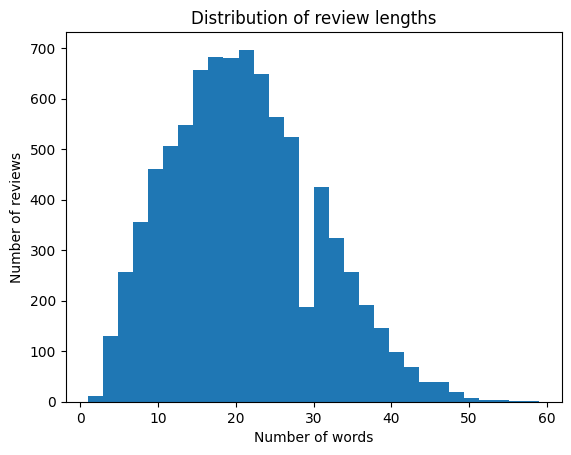

In [6]:
#Review length distribution
plt.hist(df_stats["N_WORDS"], bins=30)
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.title("Distribution of review lengths")
plt.show()

Il grafico conferma quanto osservato dalle statistiche precedenti e permette di analizzare più nel dettaglio la distribuzione della lunghezza delle recensioni. La maggior parte dei testi si concentra infatti intorno alle 15–25 parole, mentre le recensioni più lunghe diventano progressivamente meno frequenti. La distribuzione presenta quindi una coda verso destra, dovuta alla presenza di un numero limitato di recensioni di lunghezza maggiore.


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

In questa fase viene introdotto DistilBERT, il modello Transformer pre-addestrato che verrà utilizzato per l’analisi delle recensioni. Insieme al modello viene caricato il relativo tokenizer, necessario per trasformare il testo in una rappresentazione numerica che possa essere elaborata dal Transformer.

Il tokenizer verrà inizialmente applicato ad alcuni campioni del dataset per analizzarne l’output e comprendere come le recensioni vengono rappresentate prima di essere fornite al modello. I campioni tokenizzati verranno quindi passati attraverso DistilBERT, osservando la struttura dell’output prodotto dal modello.

In [7]:
#DistilBERT model and Tokenizer loading
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Per osservare il funzionamento del tokenizer, questo viene inizialmente applicato a una singola recensione del training set. Viene quindi visualizzato sia il testo originale sia l'output prodotto dalla tokenizzazione.

In [8]:
#Tokenization of a sample review
text = train_dataset[0]["text"]
print(text)

tokens = tokenizer(text, return_tensors = "pt")
tokens = {key: value.to(device) for key, value in tokens.items()}
print(tokens)


the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]], device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}


L'output del tokenizer mostra come il testo venga trasformato nella rappresentazione numerica richiesta da DistilBERT. In particolare, input_ids contiene gli identificatori numerici dei token in cui è stata suddivisa la recensione, mentre attention_mask indica quali posizioni devono essere considerate dal modello: il valore 1 identifica i token effettivi del testo, mentre 0 viene utilizzato per eventuali posizioni di padding, di cui si parlerà in seguito. In alcuni modelli della famiglia BERT possono essere presenti anche i token_type_ids, utilizzati per indicare a quale segmento della sequenza appartiene ciascun token. DistilBERT, tuttavia, non utilizza questo tipo di informazione, per cui i suoi input principali sono input_ids e attention_mask.

Gli input ottenuti dalla tokenizzazione vengono quindi forniti a DistilBERT per osservare la rappresentazione prodotta dal modello pre-addestrato. In questa fase il modello viene utilizzato solamente per eseguire una forward pass, senza effettuare alcun aggiornamento dei suoi parametri.

In [9]:
#DistilBERT model output
with torch.no_grad():
  outputs = model(
      input_ids = tokens["input_ids"],
      #token_type_ids=tokens["token_type_ids"],
      attention_mask = tokens["attention_mask"]
  )
  print(outputs)
  print(outputs.last_hidden_state.shape)

BaseModelOutput(last_hidden_state=tensor([[[-0.0332, -0.0168,  0.0194,  ...,  0.0476,  0.5834,  0.3036],
         [-0.0235, -0.0555, -0.3638,  ...,  0.1877,  0.5781, -0.1577],
         [-0.0516, -0.1014, -0.1511,  ...,  0.1503,  0.2649, -0.1575],
         ...,
         [-0.2214,  0.0666, -0.1378,  ...,  0.0319,  0.0833, -0.2145],
         [ 0.6647,  0.2524,  0.0299,  ...,  0.0841, -0.4030, -0.4060],
         [ 0.3342,  0.5060,  0.4131,  ...,  0.1109, -0.2385, -0.2486]]],
       device='cuda:0'), hidden_states=None, attentions=None)
torch.Size([1, 47, 768])


Il last_hidden_state ottenuto ha dimensione [1, 47, 768]: la prima dimensione rappresenta il numero di campioni elaborati, la seconda il numero di token della recensione e la terza la dimensione della rappresentazione prodotta da DistilBERT per ciascun token. In questo caso, quindi, il modello restituisce un vettore di 768 valori per ognuno dei 47 token della recensione.

Dopo aver analizzato una singola recensione, lo stesso procedimento viene applicato a un insieme di 10 recensioni selezionate casualmente dal training set. I testi vengono tokenizzati insieme e successivamente elaborati da DistilBERT come un unico batch.

Poiché le recensioni possono avere lunghezze diverse, vengono utilizzati padding e truncation. Il padding aggiunge speciali token di riempimento [PAD] alle sequenze più corte, in modo che tutte le sequenze dello stesso batch abbiano la stessa lunghezza, pari a quella della sequenza più lunga, e possano essere raccolte in un unico tensore. La truncation, invece, interviene sulle sequenze che superano la lunghezza massima accettata dal modello, eliminando i token in eccesso. I token aggiunti tramite padding vengono ignorati dal modello grazie all'attention_mask, che assegna valore 1 ai token effettivi e 0 a quelli di padding.

In [10]:
#Processing multiple reviews
indices = random.sample(range(len(train_dataset)), 10)
texts = [train_dataset[i]["text"] for i in indices]


tokens = tokenizer(
    texts,
    padding = True,
    truncation = True,
    return_tensors = "pt"
)

tokens = {key: value.to(device) for key, value in tokens.items()}
with torch.no_grad():
    outputs = model(
        input_ids=tokens["input_ids"],
        attention_mask=tokens["attention_mask"]
    )

print(outputs.last_hidden_state.shape)


torch.Size([10, 50, 768])


Si osserva che, in questa esecuzione, la lunghezza delle sequenze è pari a 42 anziché 47, poiché le 10 recensioni selezionate casualmente sono diverse da quella analizzata in precedenza e vengono uniformate, tramite padding, alla lunghezza della recensione più lunga del batch.

---
### Exercise 1.3: A Stable Baseline
In questo esercizio viene costruita una prima baseline per il task di sentiment analysis, utilizzando DistilBERT come feature extractor. Come osservato nell'esercizio precedente, l'ultimo layer del modello produce un vettore di 768 valori per ciascun token della recensione. Per addestrare un classificatore è però necessario ottenere una singola rappresentazione per ogni recensione.
A questo scopo viene utilizzata la rappresentazione associata al token [CLS], inserito all'inizio di ogni sequenza. Attraverso i layer Transformer, la sua rappresentazione viene costruita tenendo conto anche degli altri token della recensione e può quindi essere utilizzata come rappresentazione complessiva del testo. Il vettore di 768 valori associato a [CLS] viene pertanto utilizzato come feature vector della recensione.
DistilBERT viene mantenuto pre-addestrato, senza aggiornarne i parametri, mentre le feature così estratte vengono utilizzate per addestrare un classificatore SVM sul training set. Il classificatore ottenuto viene successivamente valutato sul test set, permettendo di ottenere una baseline di riferimento con cui confrontare i successivi approcci di fine-tuning.

Per estrarre le feature dalle recensioni, DistilBERT viene utilizzato direttamente come feature extractor. I testi vengono elaborati in piccoli batch: ciascun batch viene prima tokenizzato e successivamente fornito al modello pre-addestrato. Dall'ultimo hidden layer viene quindi selezionata, per ogni recensione, solamente la rappresentazione associata al token [CLS], ottenendo un singolo vettore di feature per ciascun testo. L'elaborazione a batch permette inoltre di limitare l'utilizzo della memoria, evitando di mantenere contemporaneamente le rappresentazioni di tutti i token dell'intero dataset.

In [11]:
# Extract CLS features from a dataset
def extract_cls_features(dataset, model, tokenizer, device, batch_size=32):
    cls_features = []

    model.eval()

    for i in range(0, len(dataset), batch_size):
        texts = dataset["text"][i:i + batch_size]

        # Tokenize the current batch
        tokens = tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        # Move inputs to the selected device
        tokens = {
            key: value.to(device)
            for key, value in tokens.items()
        }

        # Extract DistilBERT representations
        with torch.no_grad():
            outputs = model(**tokens)

        # Keep only the CLS representation
        batch_cls = outputs.last_hidden_state[:, 0, :]
        cls_features.extend(batch_cls.cpu().numpy())

    return cls_features


# Extract CLS features from the three dataset splits
train_features = extract_cls_features(
    train_dataset, model, tokenizer, device
)

val_features = extract_cls_features(
    val_dataset, model, tokenizer, device
)

test_features = extract_cls_features(
    test_dataset, model, tokenizer, device
)

# Extract the corresponding labels
train_labels = train_dataset["label"]
val_labels = val_dataset["label"]
test_labels = test_dataset["label"]

Le feature estratte tramite DistilBERT vengono ora utilizzate per addestrare un classificatore SVM lineare sul training set. Una volta addestrato, il modello viene valutato sui validation e test set, confrontando le predizioni ottenute con le rispettive etichette reali.

In [12]:
#SVM training and evaluation
classifier = LinearSVC()
classifier.fit(train_features, train_labels)

val_predictions = classifier.predict(val_features)
print("Validation report:")
print(classification_report(val_labels, val_predictions))

test_predictions = classifier.predict(test_features)
print("Test report:")
print(classification_report(test_labels, test_predictions))

Validation report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       533
           1       0.84      0.80      0.82       533

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.82      1066
weighted avg       0.82      0.82      0.82      1066

Test report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       533
           1       0.81      0.78      0.80       533

    accuracy                           0.80      1066
   macro avg       0.80      0.80      0.80      1066
weighted avg       0.80      0.80      0.80      1066



Il classificatore SVM lineare raggiunge un'accuracy di circa 0.82 sul validation set e 0.80 sul test set. Le prestazioni ottenute sui due split risultano quindi abbastanza simili, indicando che il classificatore mantiene un comportamento comparabile anche sui dati non utilizzati durante l'addestramento. Inoltre, i valori di precision, recall e F1-score risultano abbastanza bilanciati tra le due classi, coerentemente con la distribuzione equilibrata delle recensioni positive e negative osservata nel dataset. Nel complesso, questi risultati mostrano che le rappresentazioni estratte dal modello DistilBERT pre-addestrato contengono già informazioni utili per distinguere il sentiment delle recensioni, pur senza effettuare alcun fine-tuning del Transformer. Le prestazioni ottenute costituiscono quindi la baseline di riferimento con cui confrontare i successivi approcci di adattamento del modello.


## Exercise 2: Fine-tuning DistilBERT


---
### Exercise 2.1: Token Preprocessing
In questo esercizio le recensioni vengono preparate per il successivo fine-tuning di DistilBERT. A differenza dell'esercizio precedente, in cui la tokenizzazione rappresentava solamente un passaggio intermedio per estrarre le features dal modello, in questo caso il risultato della tokenizzazione viene aggiunto direttamente al dataset. Tramite Dataset.map, a ogni recensione vengono quindi associati gli input_ids e l'attention_mask, che costituiranno gli input di DistilBERT durante l'addestramento. In questo modo, la tokenizzazione viene eseguita una sola volta e non deve essere ripetuta a ogni batch.

In [13]:
#Dataset tokenization
def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True
    )

tokenized_train = train_dataset.map(tokenize_function)
tokenized_val = val_dataset.map(tokenize_function)
tokenized_test = test_dataset.map(tokenize_function)

#Check
print(tokenized_train[0])
print(tokenized_train.column_names)

print(tokenized_val[0])
print(tokenized_val.column_names)

print(tokenized_test[0])
print(tokenized_test.column_names)



Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1, 'input_ids': [101, 1996, 2600, 2003, 16036, 2000, 2022, 1996, 7398, 2301, 1005, 1055, 2047, 1000, 16608, 1000, 1998, 2008, 2002, 1005, 1055, 2183, 2000, 2191, 1037, 17624, 2130, 3618, 2084, 7779, 29058, 8625, 13327, 1010, 3744, 1011, 18856, 19513, 3158, 5477, 4168, 2030, 7112, 16562, 2140, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
{'text': 'compassionately explores the seemingly irreconcilable situation between conservative christian


---
### Exercise 2.2: Setting up the Model to be Fine-tuned
In questo esercizio viene preparato il modello che sarà utilizzato per il successivo fine-tuning sul task di sentiment analysis. A differenza della baseline precedente, in cui DistilBERT veniva utilizzato solamente come feature extractor e la classificazione era affidata a un SVM separato, viene ora caricato AutoModelForSequenceClassification. Questo modello combina DistilBERT con una classification head collegata alla rappresentazione del token [CLS], che permette di ottenere direttamente una predizione tra le due classi, positiva e negativa. DistilBERT viene inizializzato con i pesi pre-addestrati, mentre la nuova classification head viene inizializzata per il task di classificazione binaria. Il modello così costruito verrà poi addestrato tramite fine-tuning nell'esercizio successivo.

In [14]:
#Load DistilBERT with a classification head
classification_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



---
### Exercise 2.3: Fine-tuning DistilBERT
In questo esercizio viene effettuato il fine-tuning di DistilBERT sul training set del dataset. Le diverse componenti necessarie per l’addestramento vengono definite nei passaggi seguenti.


Per costruire correttamente i batch durante l'addestramento viene utilizzato DataCollatorWithPadding. Le recensioni tokenizzate nell'esercizio precedente possono infatti avere lunghezze diverse e non possono essere inserite direttamente nello stesso batch. Il data collator applica quindi il padding dinamicamente, uniformando le sequenze alla lunghezza della più lunga presente in ciascun batch. In questo modo viene aggiunto solo il padding necessario al momento della costruzione del batch.

In [15]:
#Create the data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Per valutare le prestazioni del modello durante il fine-tuning viene definita una funzione che riceve i logits prodotti dal modello e le etichette reali. Le predizioni vengono ottenute selezionando, per ciascun campione, la classe con logit maggiore. A partire da queste predizioni vengono quindi calcolate accuracy, precision, recall e F1-score.

In [16]:
#Compute classification metrics
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    report = classification_report(
        labels,
        predictions,
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1": report["macro avg"]["f1-score"]
    }

Prima di avviare il fine-tuning vengono definiti, tramite TrainingArguments, i principali parametri che regolano il processo di addestramento. In particolare, viene impostato un learning rate, vengono utilizzati batch di 16 campioni sia per il training sia per la valutazione e l'addestramento viene eseguito per 5 epoche.

Al termine di ogni epoca vengono effettuate la valutazione sul validation set e il salvataggio del modello. Tra i diversi checkpoint viene infine selezionato automaticamente quello che ha ottenuto il miglior F1-score sul validation set, che verrà utilizzato come modello finale.

In [17]:
#Training configuration
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)


Dopo aver definito tutte le componenti necessarie, viene configurato il Trainer, specificando il modello, i parametri di addestramento, i dataset di training e validation, il data collator e la funzione per il calcolo delle metriche. Viene inoltre introdotto un criterio di early stopping basato sulla validation loss: se questa non migliora per due epoche consecutive, l'addestramento viene interrotto, evitando di proseguire quando il modello non mostra più un miglioramento su questo criterio. Tra i checkpoint ottenuti viene comunque mantenuto quello con F1-score più elevato sul validation set. Il fine-tuning di DistilBERT viene infine avviato tramite trainer.train().

In [18]:
#Model fine-tuning
class LossEarlyStoppingCallback(TrainerCallback):
    def __init__(self, patience=2):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        current_loss = metrics.get("eval_loss")

        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            control.should_training_stop = True

        return control


trainer = Trainer(
    model=classification_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[LossEarlyStoppingCallback(patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.412667,0.393487,0.830206,0.843539,0.830206,0.828543
2,0.241995,0.406149,0.843340,0.844661,0.843340,0.843189
3,0.140321,0.588761,0.841463,0.843915,0.841463,0.841180


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1602, training_loss=0.26499424623639395, metrics={'train_runtime': 145.8885, 'train_samples_per_second': 292.346, 'train_steps_per_second': 18.302, 'total_flos': 323059008078528.0, 'train_loss': 0.26499424623639395, 'epoch': 3.0})

Durante il fine-tuning, la training loss diminuisce progressivamente, mentre la validation loss raggiunge il valore minimo alla prima epoca e aumenta nelle due epoche successive. Poiché la validation loss non migliora per due epoche consecutive, il criterio di early stopping interrompe l'addestramento alla terza epoca, prima del limite massimo di cinque epoche. Nel frattempo, accuracy e F1-score sul validation set mostrano variazioni più contenute. Tra i checkpoint ottenuti viene infine mantenuto quello con F1-score più elevato, secondo il criterio di selezione definito.

In una prima esecuzione, il modello era stato addestrato per cinque epoche senza utilizzare un criterio di early stopping. Sebbene le metriche di classificazione sul validation set continuassero a mostrare piccoli miglioramenti, si osservava un progressivo aumento della validation loss nelle ultime epoche, accompagnato da una continua diminuzione della training loss. Questo comportamento suggeriva un crescente adattamento del modello ai dati di training e quindi un possibile fenomeno di overfitting. Per questo motivo, l'addestramento è stato successivamente modificato introducendo un criterio di early stopping basato sulla validation loss: se questa non migliora per due epoche consecutive, il training viene interrotto.

Terminato il fine-tuning, il modello viene valutato sul test set per misurarne le prestazioni finali e verificarne la capacità di generalizzazione su dati non utilizzati per l'addestramento.

In [19]:
#Evaluate the final model on the test set
test_results = trainer.predict(tokenized_test)

#Organize the test metrics in a table
test_metrics = pd.DataFrame({
    "Score": [
        test_results.metrics["test_loss"],
        test_results.metrics["test_accuracy"],
        test_results.metrics["test_precision"],
        test_results.metrics["test_recall"],
        test_results.metrics["test_f1"]
    ]
}, index=["Loss", "Accuracy", "Precision", "Recall", "F1-score"])

test_metrics

,Score
Loss,0.428986
Accuracy,0.848968
Precision,0.849412
Recall,0.848968
F1-score,0.848920


Sul test set, accuracy, precision, recall e F1-score si attestano tutte intorno a 0.85, mostrando prestazioni complessivamente bilanciate tra le due classi. Rispetto alla baseline ottenuta utilizzando DistilBERT come feature extractor e il classificatore SVM, che raggiungeva un'accuracy di circa 0.80 sul test set, il fine-tuning completo di DistilBERT porta quindi a un miglioramento delle prestazioni. Il modello mostra inoltre una buona capacità di generalizzazione, mantenendo risultati elevati anche su dati non utilizzati durante l'addestramento e la selezione del modello.


---

## Exercise 3: Choose your Own Adventure




---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis
Nell'esercizio precedente è stato effettuato il fine-tuning completo di DistilBERT, aggiornando tutti i parametri del modello durante l'addestramento. Sebbene questo approccio permetta di adattare efficacemente il modello al task di sentiment analysis, può risultare computazionalmente costoso.

In questo esercizio viene quindi esplorata una strategia di Parameter-Efficient Fine-Tuning (PEFT), con l'obiettivo di adattare DistilBERT aggiornando solamente una piccola parte dei parametri. In particolare, verrà utilizzata LoRA (Low-Rank Adaptation), che introduce un numero limitato di parametri addestrabili mantenendo congelati i pesi originali del modello. Le prestazioni ottenute verranno infine confrontate con quelle del fine-tuning completo effettuato nell'esercizio precedente.

In [20]:
#LoRA model configuration
lora_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

#Apply LoRA to the model
lora_model = get_peft_model(
    lora_model,
    lora_config
)

#Display the number of trainable parameters
lora_model.print_trainable_parameters()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


Si osserva che, per applicare l'approccio LoRA descritto precedentemente, vengono selezionate le componenti di query q_lin e value v_lin dei layer di attention di DistilBERT. Il parametro r=8 determina la dimensione delle matrici aggiuntive introdotte da LoRA, mentre lora_alpha=16 ne regola il contributo e lora_dropout=0.1 introduce una forma di regolarizzazione durante l'addestramento. Infine, viene visualizzato il numero di parametri effettivamente addestrabili, che permetterà di quantificare l'efficienza dell'approccio rispetto al fine-tuning completo.

Il modello configurato con LoRA viene quindi addestrato utilizzando la stessa pipeline impiegata per il fine-tuning completo. Per rendere il confronto tra i due approcci il più diretto possibile, vengono mantenuti gli stessi principali parametri di addestramento e viene utilizzato nuovamente il Trainer di HuggingFace. La differenza fondamentale è che, in questo caso, viene aggiornata solamente una piccola parte dei parametri del modello, mentre la maggior parte dei pesi pre-addestrati di DistilBERT rimane congelata.

In [21]:
#LoRA training configuration
training_args_lora = TrainingArguments(
    output_dir="./results_lora",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

In [22]:
#LoRA training
trainer_lora = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[LossEarlyStoppingCallback(patience=2)]
)

trainer_lora.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.554564,0.427409,0.809568,0.810365,0.809568,0.809446
2,0.428952,0.404083,0.815197,0.817073,0.815197,0.814923
3,0.411431,0.394637,0.822702,0.822757,0.822702,0.822694
4,0.403194,0.388663,0.826454,0.827868,0.826454,0.826267
5,0.396673,0.387480,0.824578,0.825183,0.824578,0.824496


TrainOutput(global_step=2670, training_loss=0.43896280924479164, metrics={'train_runtime': 158.7091, 'train_samples_per_second': 268.731, 'train_steps_per_second': 16.823, 'total_flos': 547566212307648.0, 'train_loss': 0.43896280924479164, 'epoch': 5.0})

Terminato l'addestramento, il modello adattato tramite LoRA viene valutato sui validation e test set, in modo da misurarne le prestazioni finali e confrontarle successivamente con quelle ottenute tramite il fine-tuning completo.

In [23]:
#Evaluate the LoRA model on the test set
test_results_lora = trainer_lora.predict(tokenized_test)

#Organize the test metrics in a table
test_metrics_lora = pd.DataFrame({
    "Score": [
        test_results_lora.metrics["test_loss"],
        test_results_lora.metrics["test_accuracy"],
        test_results_lora.metrics["test_precision"],
        test_results_lora.metrics["test_recall"],
        test_results_lora.metrics["test_f1"]
    ]
}, index=["Loss", "Accuracy", "Precision", "Recall", "F1-score"])

test_metrics_lora

,Score
Loss,0.413120
Accuracy,0.816135
Precision,0.816777
Recall,0.816135
F1-score,0.816042


In [24]:
#Compare full fine-tuning and LoRA test performance
comparison = pd.DataFrame({
    "Full Fine-Tuning": [
        test_results.metrics["test_accuracy"],
        test_results.metrics["test_precision"],
        test_results.metrics["test_recall"],
        test_results.metrics["test_f1"]
    ],
    "LoRA": [
        test_results_lora.metrics["test_accuracy"],
        test_results_lora.metrics["test_precision"],
        test_results_lora.metrics["test_recall"],
        test_results_lora.metrics["test_f1"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

comparison

,Full Fine-Tuning,LoRA
Accuracy,0.848968,0.816135
Precision,0.849412,0.816777
Recall,0.848968,0.816135
F1-score,0.848920,0.816042


In questa esecuzione, il modello adattato tramite LoRA raggiunge un'accuracy e un F1-score di circa 0.82 sul test set. Le prestazioni risultano inferiori rispetto al fine-tuning completo di DistilBERT, che aveva raggiunto un'accuracy di circa 0.85 sul test set. Tuttavia, LoRA richiede l'aggiornamento di soli 739,586 parametri su circa 67.7 milioni, corrispondenti a circa l'1.09% dei parametri complessivi del modello. I risultati mostrano quindi il vantaggio del parameter-efficient fine-tuning: LoRA mantiene prestazioni relativamente vicine a quelle del fine-tuning completo pur addestrando solamente una piccola frazione dei parametri del modello.